In [72]:
%pip install seaborn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [73]:
df = pd.read_csv("CO2 Emissions_Canada.csv")

In [74]:
df.head()

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Legal Limit
0,2.0,4,Z,9.9,6.7,8.5,33,196,1
1,2.4,4,Z,11.2,7.7,9.6,29,221,1
2,1.5,4,Z,6.0,5.8,5.9,48,136,1
3,3.5,6,Z,12.7,9.1,11.1,25,255,0
4,3.5,6,Z,12.1,8.7,10.6,27,244,1


In [75]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Legal Limit
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699,0.497630
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679,0.500028
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000,0.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000,0.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000,0.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000,1.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000,1.000000


In [76]:
df.drop(['Make', 'Model', 'Vehicle Class', 'Transmission'], axis=1, errors='ignore', inplace=True)
df.head()

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Legal Limit
0,2.0,4,Z,9.9,6.7,8.5,33,196,1
1,2.4,4,Z,11.2,7.7,9.6,29,221,1
2,1.5,4,Z,6.0,5.8,5.9,48,136,1
3,3.5,6,Z,12.7,9.1,11.1,25,255,0
4,3.5,6,Z,12.1,8.7,10.6,27,244,1


In [77]:
df_encoded = pd.get_dummies(df, columns=['Fuel Type'], prefix='', prefix_sep='', drop_first=True)
df_encoded.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Legal Limit,E,N,X,Z
0,2.0,4,9.9,6.7,8.5,33,196,1,False,False,False,True
1,2.4,4,11.2,7.7,9.6,29,221,1,False,False,False,True
2,1.5,4,6.0,5.8,5.9,48,136,1,False,False,False,True
3,3.5,6,12.7,9.1,11.1,25,255,0,False,False,False,True
4,3.5,6,12.1,8.7,10.6,27,244,1,False,False,False,True


In [78]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Legal Limit,E,N,X,Z
0,2,4,9,6,8,33,196,1,0,0,0,1
1,2,4,11,7,9,29,221,1,0,0,0,1
2,1,4,6,5,5,48,136,1,0,0,0,1
3,3,6,12,9,11,25,255,0,0,0,0,1
4,3,6,12,8,10,27,244,1,0,0,0,1


X and Y data

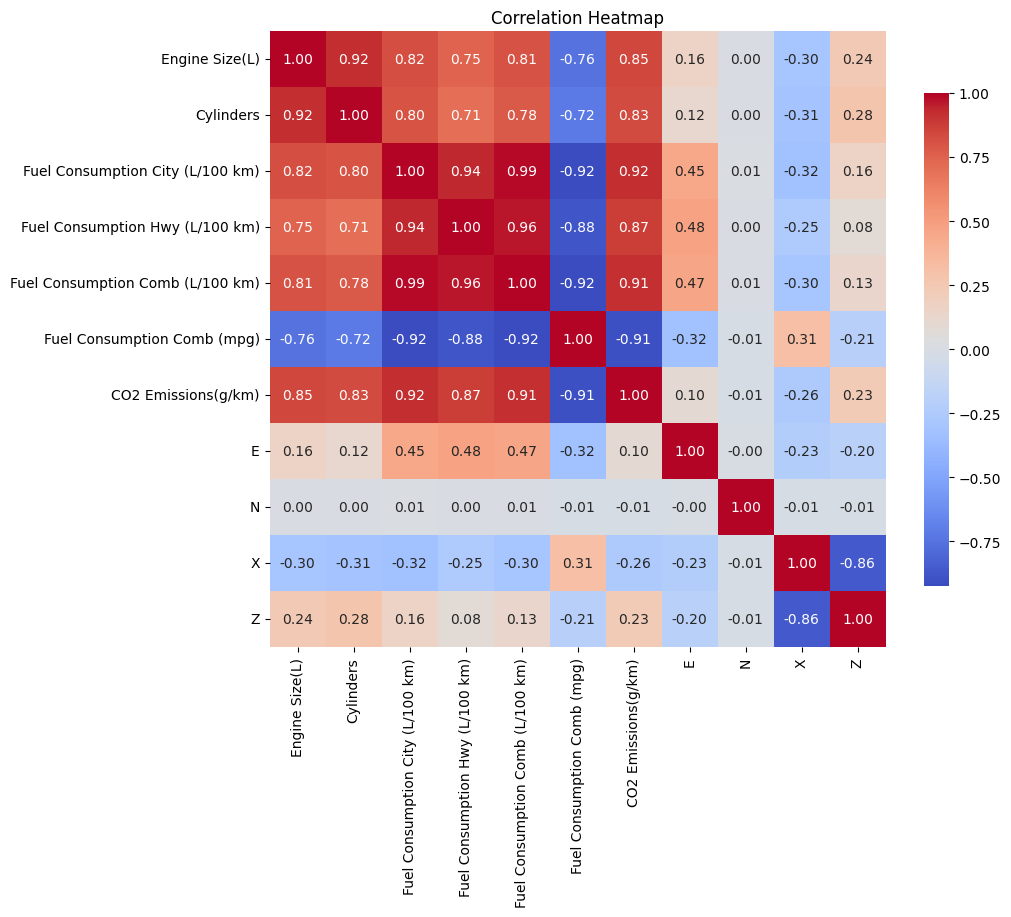

In [79]:
df_d = df_encoded.drop(['Legal Limit'], axis=1, errors='ignore', inplace=True)
numeric_df = df_encoded.select_dtypes(include=['number'])
# Compute the correlation matrix
correlation_matrix = numeric_df.corr()
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
# Create a heatmap using Seaborn
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
# Set plot title
plt.title('Correlation Heatmap')
# Display the heatmap
plt.show()

In [80]:
print(df_encoded.columns)
x = df_encoded[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'E', 'N', 'X',
       'Z']]
Y = df_encoded['CO2 Emissions(g/km)']

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'E', 'N', 'X',
       'Z'],
      dtype='object')


Test and train data split

In [81]:
x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.20, random_state=9)

In [82]:
x_regression = LinearRegression().fit(x_train, Y_train)
print(x_regression.intercept_)
print(x_regression.coef_)

109.48404751272619
[   0.28715596    1.67362602    6.97607554    5.94324536    5.89173612
   -1.15376559 -135.12478998 -110.83560335  -29.94027994  -30.91352903]


In [83]:
Y_prediction = x_regression.predict(x_train)

Plot

In [84]:
Y_pred_train = x_regression.predict(x_train)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_train = mean_absolute_error(Y_train, Y_pred_train)
mse_train = mean_squared_error(Y_train, Y_pred_train)
r2_train = r2_score(Y_train, Y_pred_train)
# Print the results
print("Training Metrics:")
print(f'Mean Absolute Error for Test data: {mae_train}')
print(f'Mean Squared Error for Test data: {mse_train}')
print(f'R-squared for Test data: {r2_train}')

Training Metrics:
Mean Absolute Error for Test data: 4.2800998481128065
Mean Squared Error for Test data: 35.54998617853156
R-squared for Test data: 0.9894777669145778


In [86]:
Y_prediction = x_regression.predict(x_test)

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_test = mean_absolute_error(Y_test, Y_prediction)
mse_test = mean_squared_error(Y_test, Y_prediction)
r2_test = r2_score(Y_test, Y_prediction)
# Print the results
print("Testing Metrics:")
print(f'Mean Absolute Error for Train data: {mae_test}')
print(f'Mean Squared Error for Train data: {mse_test}')
print(f'R-squared for Train data: {r2_test}')

Testing Metrics:
Mean Absolute Error for Train data: 4.271695290000704
Mean Squared Error for Train data: 35.21328883973718
R-squared for Train data: 0.9901822302423722
